In [4]:
import ir_datasets, pandas as pd

ds = ir_datasets.load("beir/nfcorpus/test")
docs = pd.DataFrame(ds.docs_iter())
queries = pd.DataFrame(ds.queries_iter())
qrels = pd.DataFrame(ds.qrels_iter())

[INFO] Opening /Users/bhagya/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with direct file access


In [5]:
from rank_bm25 import BM25Okapi
import numpy as np

corpus = (docs.title + " " + docs.text).tolist()
bm25 = BM25Okapi([d.lower().split() for d in corpus])

def bm25_search(q, k=20):
    s = bm25.get_scores(q.lower().split())
    idx = np.argsort(-s)[:k]
    return [(docs.doc_id[i], s[i]) for i in idx]

bm25_search(queries.text[0])[:5]

[('MED-2429', np.float64(18.703705015572396)),
 ('MED-10', np.float64(16.843006917208267)),
 ('MED-14', np.float64(15.525075456435701)),
 ('MED-1193', np.float64(15.320366755812934)),
 ('MED-2431', np.float64(15.17172092051602))]

In [6]:
rel = {qid: dict(zip(g.doc_id, g.relevance)) for qid, g in qrels[qrels.relevance > 0].groupby("query_id")}

In [7]:
def rr(ids, relevant):
    for i, d in enumerate(ids, 1):
        if d in relevant:
            return 1 / i
    return 0

def evaluate(search_fn, k=20):
    rows = []
    for q in queries.itertuples():
        if q.query_id in rel:
            ids = [d for d, _ in search_fn(q.text, k)]
            rows.append((q.query_id, rr(ids, rel[q.query_id])))
    return pd.DataFrame(rows, columns=["query_id", "rr"])


In [8]:
bm25_res = evaluate(bm25_search)

print("mrr:", bm25_res.rr.mean())

mrr: 0.46921054761060893


<Axes: >

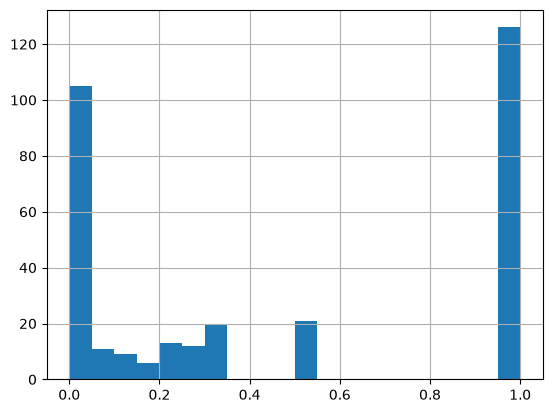

In [9]:
bm25_res.rr.hist(bins=20)